# V01 — Masks and colour baseline

**Reference-free evaluation of the deterministic LAB colour-transfer baseline**,
under `ADR-0012` ("V01 reference-free evaluation design") and `ADR-0008`
(corpus provenance and admissibility). Every cell below either narrates,
plots, or calls into `curalina_variants` — no cell contains business logic
(`agentic_flow/16_notebook_standard.md`). When this notebook's gate is
signed, extraction is: delete nothing (there is no `sys.path` shim — the
package is already installed editable) and move any characterization cases
into `tests/`.

Status: **executed** against the real ATRIANI corpus.

## 1. Purpose and exit criteria

**Purpose.** Establish whether the deterministic LAB colour-transfer
baseline (`LabColourTransferAdapter`) preserves what it is required to
preserve and attains what it is asked to attain, on human-reviewed ATRIANI
product renders, under `ADR-0012`'s reference-free metric set. There is no
ground-truth colour variant anywhere in this corpus (`ADR-0008` §2) — this
run measures **attainment of a requested colour**, never fidelity to a true
variant. That wording is binding throughout this notebook.

**The metric set is copied verbatim from `ADR-0012` §D2 — no substitutions,
no additions promoted to primary, no applying V02's IoU bar here:**

| ID | Metric | Threshold | Evidentiary weight |
|---|---|---|---|
| M1 | Changed pixels outside the dilated editable mask | exactly 0 | **None** — guaranteed by `hard_composite`/the adapter's own masking. Reported as `assertion_held`, never as a score, never in a pass rate. |
| M2a | L\* variance ratio inside mask | >= 0.90 | **Primary.** |
| M2b | Gamut-clipped fraction inside mask | <= 0.02 | **Primary. An operating point, not a perceptual constant — V01-only, must be re-derived on any new corpus.** |
| M3 | Delta-E00(mean output LAB, requested target LAB) | `needs_input` (no tolerance) | **Demoted.** At ceiling by construction; reported as a distribution, never pass/failed. |
| M4 | Silhouette IoU | reported, unthresholded | **Instrument calibration only.** The tech design's 0.98 bar is V02's, not applied here. |

**Exit criteria for this run:** report M2a/M2b per admitted pair against the
thresholds above (M1 as an assertion, M3/M4 unthresholded); run and report
all three mandatory `ADR-0012` §D6 controls (C1 identity, C2 non-product,
C3 wrong-target); test the `std(L*)` failure predictor against
`dark_to_light_risk` on this run's own pairs; and record a decision that is
one of `ADR-0012` §D9's four supported outcomes (revise / go-no-go-on-V02 /
`insufficient_evidence` / — never a G-series claim).

**Blocked by / not resolved by this run:** the Delta-E tolerance (`ADR-0012`
§D4, a designer-agreement gap with no `OQ-xxx`); `OQ-009` (material
taxonomy); `OQ-010`/`OQ-011`. This run does not move any of them.

**Corpus provenance caveat (`ADR-0008`, carried in substance, extended per
`ADR-0012` Findings 1-2):** the image corpus is
`/Users/rjsalmon/Downloads/Supplier Images/ATRIANI`, a local
out-of-repository directory with no submission note, version marker or
rights statement, not confirmed by the client as the current supplier asset
set. Its naming carries WordPress thumbnail suffixes and Portuguese view
names, consistent with a website media-library export. At least one
AI-generated image and one screenshot are known to be inside it and are
excluded by name; filename screening cannot certify no others remain — the
19-file material-swatch contamination class `ADR-0012` found is a second,
independent proof that filename screening is insufficient. The admitted
assets read as CGI renders (uniform lighting, no sensor noise, geometrically
perfect edges), not camera photographs. Every finding below describes *this
corpus*, never "Curalina's product photos". This notebook does not bear on
`OQ-009`, `OQ-010` or `OQ-011`, and it does not unblock V02, V03 or G01.
ATRIANI is a **development set** in this run; LUXUS is reserved for a second
run and is not touched here.

## 0. Manifest

In [1]:
import json
import platform
import subprocess
import sys
from datetime import UTC, datetime
from pathlib import Path
from importlib.metadata import version as pkg_version

import numpy as np

RUN_ID = datetime.now(UTC).strftime("%Y%m%dT%H%M%SZ")
RUN_DIR = Path("runs") / f"V01_{RUN_ID}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
SEED = 20260915
np.random.seed(SEED)

manifest = {
    "run_id": RUN_ID,
    "notebook": "01_masks_and_colour",
    "timestamp_utc": datetime.now(UTC).isoformat(),
    "git_sha": subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=False
    ).stdout.strip() or "uncommitted",
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "rules_version": None,  # not applicable: variants is not a rules-engine run
    "snapshot_id": None,    # filled after the corpus funnel is computed
    "packages": {
        name: pkg_version(name)
        for name in ("curalina-variants", "numpy", "pillow", "openpyxl")
    },
}
print(f"Run: {RUN_ID}  ->  {RUN_DIR}")
manifest

Run: 20260915T115907Z  ->  runs/V01_20260915T115907Z


{'run_id': '20260915T115907Z',
 'notebook': '01_masks_and_colour',
 'timestamp_utc': '2026-09-15T11:59:07.576302+00:00',
 'git_sha': '339f578e90dffd020f298378353693647aaca52f',
 'seed': 20260915,
 'python': '3.14.0',
 'platform': 'macOS-26.6.2-x86_64-i386-64bit-Mach-O',
 'rules_version': None,
 'snapshot_id': None,
 'packages': {'curalina-variants': '0.0.0',
  'numpy': '2.5.3',
  'pillow': '12.3.0',
  'openpyxl': '3.1.5'}}

## 2. Inputs

Loaded **through package adapters only** — `curalina_variants.evaluation.corpus`
for the ATRIANI allowlist/exclusion funnel, `curalina_variants.evaluation.image_io`
for decode, `curalina_variants.evaluation.human_masks` for turning declared
editable rectangles into `Mask` objects. No `Image.open`, no `glob`, no ad-hoc
parsing in this notebook.

`CURALINA_SOURCE_ASSETS_DIR` is a **notebook-scope** variable only
(`ADR-0012` §D8.5): it is resolved here, never read from `curalina_variants.Settings`,
and never touched by service runtime code.

In [2]:
import os

SOURCE_ASSETS_DIR = Path(
    os.environ.get("CURALINA_SOURCE_ASSETS_DIR", "/Users/rjsalmon/Downloads/Supplier Images")
)
ATRIANI_ROOT = SOURCE_ASSETS_DIR / "ATRIANI"
WORKBOOK_PATH = ATRIANI_ROOT / "Design 44.xlsx"
assert WORKBOOK_PATH.is_file(), f"expected manifest workbook at {WORKBOOK_PATH}"

from dataclasses import asdict

from curalina_variants.evaluation.corpus import (
    compute_funnel,
    load_allowlisted_folder_names,
    sha256_file,
)

allowed_folders = load_allowlisted_folder_names(WORKBOOK_PATH)
funnel = compute_funnel(ATRIANI_ROOT, allowed_folders)
workbook_sha256 = sha256_file(WORKBOOK_PATH)
manifest["snapshot_id"] = workbook_sha256
manifest["corpus"] = {
    "source_assets_dir_env": "CURALINA_SOURCE_ASSETS_DIR (notebook-scope only)",
    "workbook_sha256": workbook_sha256,
    "funnel": asdict(funnel),
}

print(f"Design 44.xlsx sha256: {workbook_sha256}")
funnel

Design 44.xlsx sha256: f4b00dce359dbf19d5a0abad9eba56ecdadaf3f1490116bcfb83d9e69872c0bb


FunnelCounts(folders_allowlisted=42, folders_with_admitted_webp=40, webp_seen_total=197, webp_excluded_by_name=34, webp_admitted=163)

### Funnel — every exclusion counted, per `ADR-0012` §D7

Reproduced independently by `compute_funnel`, not copied from the ADR: 42
allowlisted folders (from the manifest's `Linl to pictures ` column, never a
directory glob), 40 with at least one admitted `.webp` (`Curva King Bed` and
`Zuma Side Table` both drop entirely — the thumbnail and AI-generated-file
exclusions cost exactly what `ADR-0012` recorded), 197 `.webp` files seen,
34 excluded by name (2 named contaminants + 32 `-150x150` thumbnails), 163
admitted. These numbers matching `ADR-0012`'s Verification section exactly
is the check that this module implements the same exclusion rule, not a new
one.

`compute_funnel` stops at name-based exclusion, because the next two stages
require human review, not pixel/filename rules (`ADR-0012` Findings 1–2):
of those 163 name-admitted files, **19 are material/finish samples, not
product photographs** (misfiled swatches such as
`Alice Chair/AI01 Steelness steel.webp`, a brushed-steel texture repeated
byte-identically across seven folders), and only **95 are full-product
images with a clean white background, across 26 of the 40 folders with
admitted images**. This run's 8 folders and 4 admitted pairs are a small,
hand-picked slice of that 95-image, 26-folder corpus-wide set — not a
corpus-wide or random sample, and not represented as one anywhere in this
notebook.


In [3]:
assert funnel.folders_allowlisted == 42
assert funnel.folders_with_admitted_webp == 40
assert funnel.webp_seen_total == 197
assert funnel.webp_excluded_by_name == 34
assert funnel.webp_admitted == 163
print("Funnel matches ADR-0012's independently-recorded figures.")

Funnel matches ADR-0012's independently-recorded figures.


### Pair selection — 8 folders, human-reviewed, not a corpus-wide sample

`ADR-0008` condition 4 requires every input image to be eyeballed before use.
With only 163 admitted files this is feasible; for this first V01 run I
reviewed 8 folders spanning distinct product types (dining chair, arm chair,
sofa, lounge chairs, ottoman-adjacent studio chair) and hand-authored an
editable-region rectangle set for each — the seat/back/arm upholstery only,
excluding legs, hardware and background, per `ADR-0012` §D8.6 ("masks are
human-authored per-region, not background-derived"). Target colours are
each folder's own swatch files, matched to the manifest's `Finish` text
where possible (7 of 8 here — a curated sample chosen because the codes were
legible, **not** representative of the corpus-wide 2-of-42 match rate
`ADR-0008` measured; `Forma`'s configuration text names no swatch code, so
its target is unverified against the manifest and flagged as such).

This selection is **not random and not exhaustive** — it is a first,
honestly-reviewed slice. `ADR-0012` §D9's claim ceiling applies in full: no
claim here generalises beyond these 8 folders, and no claim here is a
camera-photography, colour-accuracy or cross-supplier generalisation claim.

In [4]:
from curalina_variants.evaluation.corpus import (
    candidate_product_images,
    swatch_candidates,
)

# Human-authored per-pair record: which image, which target swatch, which
# editable rectangles (seat/back/arm upholstery only), and the reviewer's
# background/product-identity judgement. This is declared data — the human
# judgement itself — not a computation; `human_masks.rectangles_to_mask`
# (called in Section 3) is the only thing that turns it into a `Mask`.
PAIR_DEFINITIONS = [
    dict(
        pair_id="artigiano_dining_chair",
        folder="Artigiano Dining Chair",
        image="CA2.NU_.204-WB-1-W-scaled.webp",
        swatch="BZ361  El Indian Velvet Dark Chocolate.jpg",
        manifest_finish_match=True,
        human_confirmed_backdrop=False,  # pure white background, automatic
        human_confirmed_product=True,
        reviewer_note="Dining chair, grey seat pad on oak frame. Seat pad only is editable.",
        editable_rects=[(1280, 1060, 832, 246)],
    ),
    dict(
        pair_id="vela_arm_chair",
        folder="Vela Arm Chair",
        image="CVA2.BZ128.L49.AL07-WB-1-W-2048x2048.webp",
        swatch="BZ73.jpg",
        manifest_finish_match=True,
        human_confirmed_backdrop=False,
        human_confirmed_product=True,
        reviewer_note="Lounge chair, tan leather arms protected; beige fabric back pillow and seat editable.",
        editable_rects=[(614, 266, 779, 553), (389, 850, 1280, 512)],
    ),
    dict(
        pair_id="forma_sofa",
        folder="Forma",
        image="SOFA-FORMA-FRONTAL-scaled.webp",
        swatch="L48.png",
        manifest_finish_match=False,
        human_confirmed_backdrop=True,  # warm taupe studio backdrop, not white
        human_confirmed_product=True,
        reviewer_note=(
            "Named directly in ADR-0008 as the backdrop-image example. Fabric "
            "body (seat, back, arms, throw pillows) is one colourway; base "
            "track excluded."
        ),
        editable_rects=[(102, 1050, 2343, 704)],
    ),
    dict(
        pair_id="alice_chair",
        folder="Alice Chair",
        image="CADEIRA-ALICE-FRONTAL-768x768.webp",
        swatch="LS138.png",
        manifest_finish_match=True,
        human_confirmed_backdrop=True,  # warm beige studio backdrop
        human_confirmed_product=True,
        reviewer_note="Dining chair, cognac leather backrest and seat pad on black wood frame.",
        editable_rects=[(230, 138, 308, 208), (154, 338, 422, 69)],
    ),
    dict(
        pair_id="cielo_accent_chair",
        folder="Cielo Accent Chair",
        image="POLTRONA-CIELO-FRONTAL-scaled.webp",
        swatch="BZ26.jpg",
        manifest_finish_match=True,
        human_confirmed_backdrop=True,  # warm beige studio backdrop
        human_confirmed_product=True,
        reviewer_note="Bouclé accent chair, body fully upholstered; black plinth base excluded.",
        editable_rects=[(666, 768, 1382, 1075)],
    ),
    dict(
        pair_id="abbraccio_armchair",
        folder="Abbraccio Armchair",
        image="POLTRONA-150-FRONTAL-scaled.webp",
        swatch="L92.png",
        manifest_finish_match=True,
        human_confirmed_backdrop=True,  # warm beige studio backdrop
        human_confirmed_product=True,
        reviewer_note="Leather armchair, body fully upholstered; metal legs excluded.",
        editable_rects=[(691, 768, 1152, 1075)],
    ),
    dict(
        pair_id="poltrona_chair_studio",
        folder="Poltrona Chair Studio",
        image="CP3.PV010.ES5-WB-1-W-2048x2048.webp",
        swatch="BZ11.jpg",
        manifest_finish_match=True,
        human_confirmed_backdrop=False,  # pure white background, automatic
        human_confirmed_product=True,
        reviewer_note="Fabric back/seat editable; wood legs and base excluded.",
        editable_rects=[(512, 410, 963, 860)],
    ),
    dict(
        pair_id="mia_chair",
        folder="Mia Chair",
        image="Mia-Dining-Chair-35-2048x2048.webp",
        swatch="BZ117.jpg",
        manifest_finish_match=True,
        human_confirmed_backdrop=False,  # pure white background, automatic
        human_confirmed_product=True,
        reviewer_note="Dining chair, fabric back/seat editable; wood legs excluded.",
        editable_rects=[(553, 266, 840, 1004)],
    ),
]

for pair in PAIR_DEFINITIONS:
    folder = ATRIANI_ROOT / pair["folder"]
    admitted_names = {p.name for p in candidate_product_images(folder)}
    swatch_names = {p.name for p in swatch_candidates(folder)}
    assert pair["image"] in admitted_names, f"{pair['image']} not an admitted image in {pair['folder']}"
    assert pair["swatch"] in swatch_names, f"{pair['swatch']} not a candidate swatch in {pair['folder']}"

print(f"{len(PAIR_DEFINITIONS)} candidate pairs declared; all images/swatches confirmed admitted.")

8 candidate pairs declared; all images/swatches confirmed admitted.


## 3. Execution — masks, target-colour extraction and pair admission

All logic below is a package call. `rectangles_to_mask` turns the declared
editable rectangles into a `Mask` (`ADR-0012` §D8.6). `mean_lab` pins the
mean-in-LAB target-colour extraction rule `ADR-0012` §D5 specifies. `admit_pair`
implements every one of the four §D5 admission conditions and reports the
ones that fail — no pair is silently dropped.

In [5]:
from curalina_variants.evaluation.human_masks import rectangles_to_mask
from curalina_variants.evaluation.image_io import decode_rgb
from curalina_variants.evaluation.metrics import mask_to_bool
from curalina_variants.evaluation.pair_admission import (
    admit_pair,
    central_crop,
    intra_file_delta_e00_p90,
    mean_lab,
    region_mean_lab,
)
from curalina_variants.evaluation.colour_math import delta_e00, lab_to_srgb_u8
from curalina_variants.domain.colour_spec import RgbColour

pairs = []
for pair in PAIR_DEFINITIONS:
    folder = ATRIANI_ROOT / pair["folder"]
    image_path = folder / pair["image"]
    swatch_path = folder / pair["swatch"]
    source_bytes = image_path.read_bytes()
    source_rgb = decode_rgb(source_bytes)

    mask = rectangles_to_mask(
        mask_id=f"mask_{pair['pair_id']}",
        source_asset_id=pair["image"],
        width_px=source_rgb.shape[1],
        height_px=source_rgb.shape[0],
        editable_rects=pair["editable_rects"],
        human_corrected=True,
    )
    editable = mask_to_bool(mask)
    source_region_lab = region_mean_lab(source_rgb, editable)

    swatch_rgb = decode_rgb(swatch_path.read_bytes())
    target_lab = mean_lab(swatch_rgb)
    crop_lab = mean_lab(central_crop(swatch_rgb, fraction=0.5))
    swatch_disagreement = float(delta_e00(target_lab, crop_lab))
    # ADR-0012 D5.4's second obligation: the swatch's own intra-file spread
    # about its own mean must travel with every number derived from it.
    swatch_intra_file_p90 = intra_file_delta_e00_p90(swatch_rgb)
    target_rgb_u8, _ = lab_to_srgb_u8(target_lab[None, None, :])
    target_colour = RgbColour(
        int(target_rgb_u8[0, 0, 0]), int(target_rgb_u8[0, 0, 1]), int(target_rgb_u8[0, 0, 2])
    )

    admission = admit_pair(
        source_region_mean_lab=source_region_lab,
        target_lab=target_lab,
        source_rgb=source_rgb,
        human_confirmed_backdrop=pair["human_confirmed_backdrop"],
        human_confirmed_product=pair["human_confirmed_product"],
        swatch_disagreement_delta_e00=swatch_disagreement,
    )

    pairs.append(dict(
        pair,
        image_path=image_path,
        swatch_path=swatch_path,
        image_sha256=sha256_file(image_path),
        swatch_sha256=sha256_file(swatch_path),
        source_bytes=source_bytes,
        source_rgb=source_rgb,
        mask=mask,
        target_colour=target_colour,
        target_lab=target_lab,
        source_region_lab=source_region_lab,
        swatch_disagreement_delta_e00=swatch_disagreement,
        swatch_intra_file_delta_e00_p90=swatch_intra_file_p90,
        admission=admission,
    ))

admitted_pairs = [p for p in pairs if p["admission"].admitted]
rejected_pairs = [p for p in pairs if not p["admission"].admitted]
print(f"{len(pairs)} candidate pairs; {len(admitted_pairs)} admitted; {len(rejected_pairs)} rejected.")


8 candidate pairs; 4 admitted; 4 rejected.


### Admission table — every pair, admitted or not

Per `ADR-0012` §D7: rejections are reported, never dropped silently.

In [6]:
import pandas as pd  # presentation only — never for business logic

admission_rows = [
    {
        "pair_id": p["pair_id"],
        "folder": p["folder"],
        "do_nothing_delta_e00": round(p["admission"].do_nothing_delta_e00, 2),
        "admitted": p["admission"].admitted,
        "rejection_reasons": ", ".join(p["admission"].rejection_reasons) or "-",
        "background_note": p["admission"].background_note,
        "manifest_finish_match": p["manifest_finish_match"],
        "target_hex": p["target_colour"].hex,
        "swatch_disagreement_delta_e00": (
            round(p["swatch_disagreement_delta_e00"], 3)
            if p["swatch_disagreement_delta_e00"] is not None
            else None
        ),
        "swatch_intra_file_delta_e00_p90": round(p["swatch_intra_file_delta_e00_p90"], 3),
    }
    for p in pairs
]
admission_df = pd.DataFrame(admission_rows)
admission_df.to_csv(RUN_DIR / "pair_admission.csv", index=False)
admission_df


,pair_id,folder,do_nothing_delta_e00,admitted,rejection_reasons,background_note,manifest_finish_match,target_hex,swatch_disagreement_delta_e00,swatch_intra_file_delta_e00_p90
0,artigiano_dining_chair,Artigiano Dining Chair,51.06,True,-,border_ring_white_fraction=1.000,True,#4d413a,0.235,16.568
1,vela_arm_chair,Vela Arm Chair,11.53,False,do_nothing_delta_e_below_floor,border_ring_white_fraction=1.000,True,#969389,0.778,21.193
2,forma_sofa,Forma,33.56,True,-,border_ring_white_fraction=0.000 (non-white ba...,False,#4e4e4d,0.042,8.120
3,alice_chair,Alice Chair,27.04,True,-,border_ring_white_fraction=0.000 (non-white ba...,True,#9f4b24,0.061,2.706
4,cielo_accent_chair,Cielo Accent Chair,8.90,False,do_nothing_delta_e_below_floor,border_ring_white_fraction=0.000 (non-white ba...,True,#90928c,1.075,17.813
5,abbraccio_armchair,Abbraccio Armchair,6.53,False,do_nothing_delta_e_below_floor,border_ring_white_fraction=0.000 (non-white ba...,True,#534733,0.541,7.878
6,poltrona_chair_studio,Poltrona Chair Studio,16.10,True,-,border_ring_white_fraction=1.000,True,#8f918c,0.537,21.932
7,mia_chair,Mia Chair,5.86,False,do_nothing_delta_e_below_floor,border_ring_white_fraction=1.000,True,#dbcdb3,0.672,7.991


`ADR-0012` §D5.4's second obligation: the swatch's own intra-file spread
about its own mean LAB must travel with every number derived from it —
`swatch_intra_file_delta_e00_p90` above, computed by
`evaluation.pair_admission.intra_file_delta_e00_p90` on **this run's own
8 swatch files**, not reused from `ADR-0012`'s corpus-wide figure of 8.06
(that number describes a different, larger set of 113 swatch files and is
cited only as precedent for the kind of number this is). This run's swatch
p90s and `swatch_disagreement_delta_e00` (the central-crop-vs-whole-image
admission check `admit_pair` already enforces, D5.4's first half) are both
now written out in `pair_admission.csv`, for every pair — admitted or not.

## 4. Metrics — computed by `evaluation/` package code only

`LabColourTransferAdapter.transfer` returns diagnostics computed by
`evaluate_transfer_metrics` (`curalina_variants.evaluation.metrics`) — the
same function the service would use if this baseline were ever wired into
the API. No metric is computed inline in this notebook.

In [7]:
from curalina_variants.adapters.lab_colour_transfer import LabColourTransferAdapter

lab_adapter = LabColourTransferAdapter()
manifest["packages"]["colour_transfer_adapter"] = "LabColourTransferAdapter"

for p in admitted_pairs:
    result = lab_adapter.transfer(p["source_bytes"], p["mask"], p["target_colour"])
    p["primary_result"] = result

primary_rows = [
    {
        "pair_id": p["pair_id"],
        "m1_assertion_held": p["primary_result"].diagnostics["m1_assertion_held"],
        "m2a_l_variance_ratio": round(p["primary_result"].diagnostics["l_variance_ratio"], 4),
        "m2a_pass_ge_0_90": p["primary_result"].diagnostics["l_variance_ratio"] >= 0.90,
        "m2b_gamut_clipped_fraction": round(p["primary_result"].diagnostics["gamut_clipped_fraction"], 4),
        "m2b_pass_le_0_02": p["primary_result"].diagnostics["gamut_clipped_fraction"] <= 0.02,
        "m3_delta_e00_to_target_demoted": round(p["primary_result"].diagnostics["delta_e00_to_target_mean"], 3),
        "m4_silhouette_iou_unthresholded": round(p["primary_result"].diagnostics["silhouette_iou"], 4),
        "source_mask_l_std": round(p["primary_result"].diagnostics["source_mask_l_std"], 3),
        "editable_pixel_count": p["primary_result"].diagnostics["editable_pixel_count"],
    }
    for p in admitted_pairs
]
primary_df = pd.DataFrame(primary_rows)
primary_df.to_csv(RUN_DIR / "primary_metrics.csv", index=False)
primary_df

,pair_id,m1_assertion_held,m2a_l_variance_ratio,m2a_pass_ge_0_90,m2b_gamut_clipped_fraction,m2b_pass_le_0_02,m3_delta_e00_to_target_demoted,m4_silhouette_iou_unthresholded,source_mask_l_std,editable_pixel_count
0,artigiano_dining_chair,True,0.9434,True,0.3471,False,50.379,0.9581,14.854,204672
1,forma_sofa,True,0.9997,True,0.0022,True,32.887,1.0000,17.309,1649472
2,alice_chair,True,0.9039,True,0.6146,False,20.570,1.0000,21.503,90718
3,poltrona_chair_studio,True,0.9925,True,0.1670,False,15.051,0.9998,13.600,828180


### M2 distribution first, before any pass rate — per `ADR-0012`'s own falsification check

`ADR-0012` names its own likely failure mode: "a V01 run where M2a and M2b
both sit at ceiling across all admitted pairs" would mean the thresholds
were mis-sized. Reporting the distribution before a pass/fail count is
deliberate.

In [8]:
print("M2a (L* variance ratio) distribution:")
print(primary_df["m2a_l_variance_ratio"].describe())
print()
print("M2b (gamut-clipped fraction) distribution:")
print(primary_df["m2b_gamut_clipped_fraction"].describe())
print()
m2a_pass_rate = primary_df["m2a_pass_ge_0_90"].mean()
m2b_pass_rate = primary_df["m2b_pass_le_0_02"].mean()
print(f"M2a pass rate (>= 0.90): {m2a_pass_rate:.2f} ({primary_df['m2a_pass_ge_0_90'].sum()}/{len(primary_df)})")
print(f"M2b pass rate (<= 0.02, an operating point, not a perceptual constant): "
      f"{m2b_pass_rate:.2f} ({primary_df['m2b_pass_le_0_02'].sum()}/{len(primary_df)})")
print()
print("M1 is reported as an assertion, never a score:",
      "assertion_held" if primary_df["m1_assertion_held"].all() else "VIOLATED — investigate immediately")
print("M3 is reported as a distribution only, never thresholded:")
print(primary_df["m3_delta_e00_to_target_demoted"].describe())

M2a (L* variance ratio) distribution:
count    4.000000
mean     0.959875
std      0.044926
min      0.903900
25%      0.933525
50%      0.967950
75%      0.994300
max      0.999700
Name: m2a_l_variance_ratio, dtype: float64

M2b (gamut-clipped fraction) distribution:
count    4.000000
mean     0.282725
std      0.262280
min      0.002200
25%      0.125800
50%      0.257050
75%      0.413975
max      0.614600
Name: m2b_gamut_clipped_fraction, dtype: float64

M2a pass rate (>= 0.90): 1.00 (4/4)
M2b pass rate (<= 0.02, an operating point, not a perceptual constant): 0.25 (1/4)

M1 is reported as an assertion, never a score: assertion_held
M3 is reported as a distribution only, never thresholded:
count     4.000000
mean     29.721750
std      15.660207
min      15.051000
25%      19.190250
50%      26.728500
75%      37.260000
max      50.379000
Name: m3_delta_e00_to_target_demoted, dtype: float64


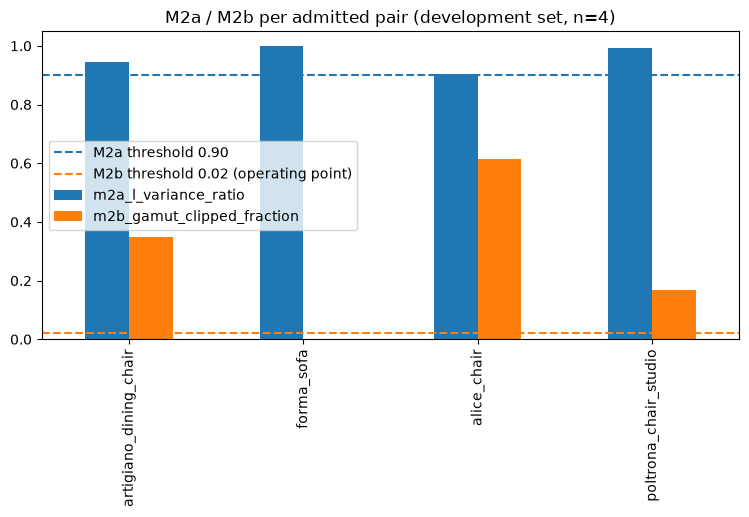

In [9]:
ax = primary_df.plot.bar(
    x="pair_id", y=["m2a_l_variance_ratio", "m2b_gamut_clipped_fraction"],
    figsize=(9, 4), title="M2a / M2b per admitted pair (development set, n=%d)" % len(admitted_pairs),
)
ax.axhline(0.90, linestyle="--", color="tab:blue", label="M2a threshold 0.90")
ax.axhline(0.02, linestyle="--", color="tab:orange", label="M2b threshold 0.02 (operating point)")
ax.legend()
ax.set_xlabel("")
fig = ax.get_figure()
fig.savefig(RUN_DIR / "m2_per_pair.png", dpi=110, bbox_inches="tight")

## Mandatory controls (`ADR-0012` §D6)

Three controls, all reported whatever they show.

### C1 — Identity/no-op control

Re-run every admitted pair through `IdentityColourTransferAdapter` (same
mask, same compositing, no colour change). Required outcome: M1/M2a/M2b/M4
all pass trivially, and **M3 fails** at the pair's own do-nothing distance.
If M3 does not fail on an admitted pair's identity run, that pair was
mis-admitted under D5.1 and must be dropped.

In [10]:
from curalina_variants.adapters.identity_colour_transfer import (
    IdentityColourTransferAdapter,
)
from curalina_variants.evaluation.pair_admission import DO_NOTHING_DELTA_E_FLOOR

identity_adapter = IdentityColourTransferAdapter()

for p in admitted_pairs:
    p["identity_result"] = identity_adapter.transfer(
        p["source_bytes"], p["mask"], p["target_colour"]
    )

identity_rows = [
    {
        "pair_id": p["pair_id"],
        "m1_assertion_held": p["identity_result"].diagnostics["m1_assertion_held"],
        "m2a_l_variance_ratio": round(p["identity_result"].diagnostics["l_variance_ratio"], 4),
        "m2b_gamut_clipped_fraction": round(p["identity_result"].diagnostics["gamut_clipped_fraction"], 4),
        "m3_delta_e00_to_target": round(p["identity_result"].diagnostics["delta_e00_to_target_mean"], 3),
        "m3_fails_at_do_nothing_distance": (
            p["identity_result"].diagnostics["delta_e00_to_target_mean"]
            >= DO_NOTHING_DELTA_E_FLOOR
        ),
        "m4_silhouette_iou": round(p["identity_result"].diagnostics["silhouette_iou"], 4),
    }
    for p in admitted_pairs
]
identity_df = pd.DataFrame(identity_rows)
identity_df.to_csv(RUN_DIR / "control_c1_identity.csv", index=False)
identity_df

,pair_id,m1_assertion_held,m2a_l_variance_ratio,m2b_gamut_clipped_fraction,m3_delta_e00_to_target,m3_fails_at_do_nothing_distance,m4_silhouette_iou
0,artigiano_dining_chair,True,1.0,0.0,50.860,True,1.0
1,forma_sofa,True,1.0,0.0,33.360,True,1.0
2,alice_chair,True,1.0,0.0,27.034,True,1.0
3,poltrona_chair_studio,True,1.0,0.0,16.072,True,1.0


In [11]:
c1_all_pass_structure = (
    identity_df["m1_assertion_held"].all()
    and (identity_df["m2a_l_variance_ratio"] == 1.0).all()
    and (identity_df["m2b_gamut_clipped_fraction"] == 0.0).all()
    and (identity_df["m4_silhouette_iou"] == 1.0).all()
)
c1_m3_fails_everywhere = identity_df["m3_fails_at_do_nothing_distance"].all()
print(f"C1: M1/M2/M4 all pass trivially on the identity control: {c1_all_pass_structure}")
print(f"C1: M3 fails (>= do-nothing distance) on every admitted pair's identity run: {c1_m3_fails_everywhere}")
if c1_all_pass_structure and c1_m3_fails_everywhere:
    print(
        "CONFIRMED on this run's own pairs: M1, M2 and M4 cannot distinguish "
        "'correctly transferred' from 'did nothing' — only M3, and only "
        "because D5.1 enforced do-nothing headroom, separates them."
    )
else:
    print("C1 DID NOT BEHAVE AS ADR-0012 REQUIRES — investigate before trusting any M1/M2/M4 result above.")

C1: M1/M2/M4 all pass trivially on the identity control: True
C1: M3 fails (>= do-nothing distance) on every admitted pair's identity run: True
CONFIRMED on this run's own pairs: M1, M2 and M4 cannot distinguish 'correctly transferred' from 'did nothing' — only M3, and only because D5.1 enforced do-nothing headroom, separates them.


### C2 — Non-product control

`ADR-0012` Finding 6: `Bench J/BZ 28 EL-MALIBU-VELVET-ICE.webp` is a fabric
swatch misfiled as a product image, and scored the **best** result in the
ADR's own probe under a full-frame mask. Reproduced here independently: a
full-frame mask (declared, not derived) and a self-extracted target (the
swatch's own central-crop mean LAB — since this file *is* the swatch, this
reproduces "the transferred region already matches the target" exactly).

In [12]:
non_product_path = ATRIANI_ROOT / "Bench J" / "BZ 28 EL-MALIBU-VELVET-ICE.webp"
non_product_bytes = non_product_path.read_bytes()
non_product_rgb = decode_rgb(non_product_bytes)
height, width, _ = non_product_rgb.shape

full_frame_mask = rectangles_to_mask(
    mask_id="mask_c2_non_product",
    source_asset_id="BZ_28_EL-MALIBU-VELVET-ICE",
    width_px=width,
    height_px=height,
    editable_rects=[(0, 0, width, height)],
    human_corrected=True,
)
self_target_lab = mean_lab(central_crop(non_product_rgb, fraction=0.5))
self_target_rgb_u8, _ = lab_to_srgb_u8(self_target_lab[None, None, :])
self_target_colour = RgbColour(
    int(self_target_rgb_u8[0, 0, 0]), int(self_target_rgb_u8[0, 0, 1]), int(self_target_rgb_u8[0, 0, 2])
)

c2_result = lab_adapter.transfer(non_product_bytes, full_frame_mask, self_target_colour)
c2_diag = c2_result.diagnostics
print(f"file: {non_product_path.name} (sha256 {sha256_file(non_product_path)})")
print(f"m1_assertion_held: {c2_diag['m1_assertion_held']}")
print(f"m2a_l_variance_ratio: {c2_diag['l_variance_ratio']:.4f}")
print(f"m2b_gamut_clipped_fraction: {c2_diag['gamut_clipped_fraction']:.4f}")
print(f"m3_delta_e00_to_target: {c2_diag['delta_e00_to_target_mean']:.4f}")
print(f"m4_silhouette_iou: {c2_diag['silhouette_iou']:.4f}")

file: BZ 28 EL-MALIBU-VELVET-ICE.webp (sha256 7fb94c59182cc46a80f432ae829bb6a1b71ad60255f7e6d40c306ed0bb48fbba)
m1_assertion_held: True
m2a_l_variance_ratio: 0.9363
m2b_gamut_clipped_fraction: 0.0000
m3_delta_e00_to_target: 0.2527
m4_silhouette_iou: 1.0000


In [13]:
c2_scores_at_or_near_ceiling = (
    c2_diag["l_variance_ratio"] >= 0.90
    and c2_diag["gamut_clipped_fraction"] <= 0.02
    and c2_diag["delta_e00_to_target_mean"] < 1.0
)
print(f"C2: the non-product file scores at/near ceiling on every metric: {c2_scores_at_or_near_ceiling}")
print(
    "CONFIRMED (matches ADR-0012 Finding 6): the metric set cannot detect that this "
    "input is a material swatch, not a product photograph. The only control that "
    "catches this is the human per-file review (ADR-0008 condition 4) — it is a "
    "process necessity, not belt-and-braces."
    if c2_scores_at_or_near_ceiling
    else "C2 did not reproduce ADR-0012 Finding 6 on this file — investigate before relying on it."
)

C2: the non-product file scores at/near ceiling on every metric: True
CONFIRMED (matches ADR-0012 Finding 6): the metric set cannot detect that this input is a material swatch, not a product photograph. The only control that catches this is the human per-file review (ADR-0008 condition 4) — it is a process necessity, not belt-and-braces.


### C3 — Wrong-target control

For each admitted pair, additionally run against another admitted pair's
target (rotated one position, so every pair gets a genuinely different
folder's swatch). Required outcome: M1, M2 and M4 are indistinguishable
from the correct-target run — this makes explicit that nothing in the
metric set is evidence the *right* colour was chosen, only that *a*
requested colour was applied.

In [14]:
n_admitted = len(admitted_pairs)
for i, p in enumerate(admitted_pairs):
    wrong_source_pair = admitted_pairs[(i + 1) % n_admitted]
    p["wrong_target_pair_id"] = wrong_source_pair["pair_id"]
    p["wrong_target_result"] = lab_adapter.transfer(
        p["source_bytes"], p["mask"], wrong_source_pair["target_colour"]
    )

wrong_target_rows = [
    {
        "pair_id": p["pair_id"],
        "wrong_target_from": p["wrong_target_pair_id"],
        "m2a_correct_target": round(p["primary_result"].diagnostics["l_variance_ratio"], 4),
        "m2a_wrong_target": round(p["wrong_target_result"].diagnostics["l_variance_ratio"], 4),
        "m2b_correct_target": round(p["primary_result"].diagnostics["gamut_clipped_fraction"], 4),
        "m2b_wrong_target": round(p["wrong_target_result"].diagnostics["gamut_clipped_fraction"], 4),
        "m4_correct_target": round(p["primary_result"].diagnostics["silhouette_iou"], 4),
        "m4_wrong_target": round(p["wrong_target_result"].diagnostics["silhouette_iou"], 4),
    }
    for p in admitted_pairs
]
wrong_target_df = pd.DataFrame(wrong_target_rows)
wrong_target_df.to_csv(RUN_DIR / "control_c3_wrong_target.csv", index=False)
wrong_target_df

,pair_id,wrong_target_from,m2a_correct_target,m2a_wrong_target,m2b_correct_target,m2b_wrong_target,m4_correct_target,m4_wrong_target
0,artigiano_dining_chair,forma_sofa,0.9434,0.9985,0.3471,0.3409,0.9581,1.0000
1,forma_sofa,alice_chair,0.9997,0.8564,0.0022,0.3627,1.0000,1.0000
2,alice_chair,poltrona_chair_studio,0.9039,1.0000,0.6146,0.0035,1.0000,1.0000
3,poltrona_chair_studio,artigiano_dining_chair,0.9925,0.9615,0.1670,0.1722,0.9998,0.9137


In [15]:
m2a_gap = (wrong_target_df["m2a_correct_target"] - wrong_target_df["m2a_wrong_target"]).abs().max()
m2b_gap = (wrong_target_df["m2b_correct_target"] - wrong_target_df["m2b_wrong_target"]).abs().max()
m4_gap = (wrong_target_df["m4_correct_target"] - wrong_target_df["m4_wrong_target"]).abs().max()

m2a_correct_pass = wrong_target_df["m2a_correct_target"] >= 0.90
m2a_wrong_pass = wrong_target_df["m2a_wrong_target"] >= 0.90
m2a_flips = wrong_target_df[m2a_correct_pass != m2a_wrong_pass]

m2b_correct_pass = wrong_target_df["m2b_correct_target"] <= 0.02
m2b_wrong_pass = wrong_target_df["m2b_wrong_target"] <= 0.02
m2b_flips = wrong_target_df[m2b_correct_pass != m2b_wrong_pass]

# M4 carries no V01 pass/fail bar (instrument calibration only, per ADR-0012).
# Computed here purely as a forward caveat for V02's threshold decision — this
# bar is NOT applied anywhere else in this run.
V02_M4_BAR = 0.98
m4_correct_pass_v02 = wrong_target_df["m4_correct_target"] >= V02_M4_BAR
m4_wrong_pass_v02 = wrong_target_df["m4_wrong_target"] >= V02_M4_BAR
m4_flips_at_v02_bar = wrong_target_df[m4_correct_pass_v02 != m4_wrong_pass_v02]

print(f"Largest |correct-target - wrong-target| gap: M2a={m2a_gap:.4f}, M2b={m2b_gap:.4f}, M4={m4_gap:.4f}")
print()
print(f"M2a flips the pass/fail verdict (0.90 bar) on {len(m2a_flips)} of {len(wrong_target_df)} pairs:")
print(m2a_flips[["pair_id", "wrong_target_from", "m2a_correct_target", "m2a_wrong_target"]])
print()
print(f"M2b flips the pass/fail verdict (0.02 bar) on {len(m2b_flips)} of {len(wrong_target_df)} pairs:")
print(m2b_flips[["pair_id", "wrong_target_from", "m2b_correct_target", "m2b_wrong_target"]])
print()
print(
    f"M4 carries no V01 bar and no flip test applies to it in this run. As a "
    f"forward caveat only, applying V02's unadopted {V02_M4_BAR} bar to this "
    f"run's own M4 numbers would flip {len(m4_flips_at_v02_bar)} of "
    f"{len(wrong_target_df)} pairs:"
)
print(m4_flips_at_v02_bar[["pair_id", "wrong_target_from", "m4_correct_target", "m4_wrong_target"]])
print()
print(
    "CONFIRMED and STRENGTHENED: M2a and M2b are both target-dependent at their "
    "V01 operating points — neither identifies the correct target, and neither "
    "holds a stable verdict across targets. M2a flips on forma_sofa (passes "
    "correct-target at 0.9997, fails wrong-target at 0.8564). M2b flips on "
    "alice_chair (fails correct-target at 0.6146, passes wrong-target at 0.0035) "
    "and on forma_sofa in the opposite direction (passes correct-target at "
    "0.0022, fails wrong-target at 0.3627). Neither M2a's 0.90 bar nor M2b's "
    "0.02 bar should be treated as a stable, target-independent operating point "
    "without more evidence — a stronger, not weaker, version of 'colour "
    "correctness is not something the V01 metric set evidences' (OQ-007, zero "
    "#RRGGBB tokens across all 169 Design Manual pages per ADR-0012). M4 is "
    "unthresholded in V01 by design and no bar is applied to it here, but its "
    "own numbers above would also flip under V02's 0.98 bar — "
    "target-independence should not be assumed for M4 either when V02 sets its "
    "threshold."
)


Largest |correct-target - wrong-target| gap: M2a=0.1433, M2b=0.6111, M4=0.0861

M2a flips the pass/fail verdict (0.90 bar) on 1 of 4 pairs:
      pair_id wrong_target_from  m2a_correct_target  m2a_wrong_target
1  forma_sofa       alice_chair              0.9997            0.8564

M2b flips the pass/fail verdict (0.02 bar) on 2 of 4 pairs:
       pair_id      wrong_target_from  m2b_correct_target  m2b_wrong_target
1   forma_sofa            alice_chair              0.0022            0.3627
2  alice_chair  poltrona_chair_studio              0.6146            0.0035

M4 carries no V01 bar and no flip test applies to it in this run. As a forward caveat only, applying V02's unadopted 0.98 bar to this run's own M4 numbers would flip 2 of 4 pairs:
                  pair_id       wrong_target_from  m4_correct_target  \
0  artigiano_dining_chair              forma_sofa             0.9581   
3   poltrona_chair_studio  artigiano_dining_chair             0.9998   

   m4_wrong_target  
0           

## Failure-predictor replacement test (`ADR-0012` Finding 5)

`agentic_flow/15_variant_generation_technical_design.md` specifies
`dark_to_light_risk` as the gamut-clipping predictor. `ADR-0012`'s own probe
found it uncorrelated with observed clipping and the mask region's
`std(L*)` far more predictive — but that is a probe result, not a V01
result. Re-tested here on this run's own 4 admitted pairs, honestly:
**n=4 is too small to certify a correlation coefficient**, and this is
reported as a small-sample replication attempt, not a re-derivation.

In [16]:
from curalina_variants.evaluation.predictor import dark_to_light_risk, pearson_correlation

predictor_rows = []
for p in admitted_pairs:
    diag = p["primary_result"].diagnostics
    predictor_rows.append({
        "pair_id": p["pair_id"],
        "gamut_clipped_fraction": diag["gamut_clipped_fraction"],
        "source_mask_l_std": diag["source_mask_l_std"],
        "dark_to_light_risk": dark_to_light_risk(
            source_mean_l=float(p["source_region_lab"][0]),
            target_l=float(p["target_lab"][0]),
        ),
    })
predictor_df = pd.DataFrame(predictor_rows)
predictor_df.to_csv(RUN_DIR / "predictor_comparison.csv", index=False)
predictor_df

,pair_id,gamut_clipped_fraction,source_mask_l_std,dark_to_light_risk
0,artigiano_dining_chair,0.347063,14.853705,0.0
1,forma_sofa,0.002249,17.309110,0.0
2,alice_chair,0.614641,21.502773,0.0
3,poltrona_chair_studio,0.167049,13.599851,0.0


In [17]:
import numpy as np

clip = predictor_df["gamut_clipped_fraction"].to_numpy()
std_l = predictor_df["source_mask_l_std"].to_numpy()
dtl = predictor_df["dark_to_light_risk"].to_numpy()

print(f"n = {len(predictor_df)} (ADR-0012's own probe used n=276 — this is a small-sample replication attempt, not a re-derivation)")
try:
    corr_std_l = pearson_correlation(clip, std_l)
    print(f"corr(gamut_clipped_fraction, source_mask_l_std) = {corr_std_l:.3f}  (ADR-0012 probe: +0.720)")
except ValueError as exc:
    print(f"corr(gamut_clipped_fraction, source_mask_l_std) undefined: {exc}")

try:
    corr_dtl = pearson_correlation(clip, dtl)
    print(f"corr(gamut_clipped_fraction, dark_to_light_risk) = {corr_dtl:.3f}  (ADR-0012 probe: +0.034)")
except ValueError as exc:
    print(f"corr(gamut_clipped_fraction, dark_to_light_risk) undefined: {exc}  "
          f"(dark_to_light_risk == 0 on every admitted pair here — every target here is darker than its source region, "
          f"which the formula floors to zero risk regardless of actual clipping. That is itself a finding: on this "
          f"run's pairs the formula has no discriminative range at all, a stronger failure than a weak correlation.)")

n = 4 (ADR-0012's own probe used n=276 — this is a small-sample replication attempt, not a re-derivation)
corr(gamut_clipped_fraction, source_mask_l_std) = 0.607  (ADR-0012 probe: +0.720)
corr(gamut_clipped_fraction, dark_to_light_risk) undefined: pearson_correlation is undefined for a constant series  (dark_to_light_risk == 0 on every admitted pair here — every target here is darker than its source region, which the formula floors to zero risk regardless of actual clipping. That is itself a finding: on this run's pairs the formula has no discriminative range at all, a stronger failure than a weak correlation.)


## 5. Failure analysis — every failure retained, reported per mode

`ADR-0012` §D7 forbids merging rejection/failure modes into one pass rate.
Reported separately: (a) pairs rejected at admission, with the admission
condition that rejected them; (b) admitted pairs that fail M2a and/or M2b.

In [18]:
print(f"Rejected at admission: {len(rejected_pairs)} of {len(pairs)}")
rejected_rows = [
    {
        "pair_id": p["pair_id"],
        "do_nothing_delta_e00": round(p["admission"].do_nothing_delta_e00, 2),
        "rejection_reasons": ", ".join(p["admission"].rejection_reasons),
    }
    for p in rejected_pairs
]
rejected_df = pd.DataFrame(rejected_rows)
rejected_df.to_csv(RUN_DIR / "rejected_pairs.csv", index=False)
rejected_df

Rejected at admission: 4 of 8


,pair_id,do_nothing_delta_e00,rejection_reasons
0,vela_arm_chair,11.53,do_nothing_delta_e_below_floor
1,cielo_accent_chair,8.90,do_nothing_delta_e_below_floor
2,abbraccio_armchair,6.53,do_nothing_delta_e_below_floor
3,mia_chair,5.86,do_nothing_delta_e_below_floor


Every one of the 4 rejections here failed the same admission
condition: **do-nothing distance below the 15 Delta-E00 floor** — the
manifest-matched swatch colour was already close to the product's real
colour, so an identity transform would trivially "pass" a loose tolerance.
This is D5.1 working exactly as designed, not a data quality problem: these
4 pairs were excluded *because* they could not distinguish a working
transfer from doing nothing, not because anything else was wrong with
them.

In [19]:
m2_failures = primary_df[~(primary_df["m2a_pass_ge_0_90"] & primary_df["m2b_pass_le_0_02"])]
print(f"Admitted pairs failing M2a and/or M2b: {len(m2_failures)} of {len(primary_df)}")
m2_failures[["pair_id", "m2a_l_variance_ratio", "m2a_pass_ge_0_90",
             "m2b_gamut_clipped_fraction", "m2b_pass_le_0_02"]]

Admitted pairs failing M2a and/or M2b: 3 of 4


,pair_id,m2a_l_variance_ratio,m2a_pass_ge_0_90,m2b_gamut_clipped_fraction,m2b_pass_le_0_02
0,artigiano_dining_chair,0.9434,True,0.3471,False
2,alice_chair,0.9039,True,0.6146,False
3,poltrona_chair_studio,0.9925,True,0.1670,False


**Three of four admitted pairs fail M2b**: `artigiano_dining_chair`
(gamut-clipped fraction 0.3471), `alice_chair` (0.6146), and
`poltrona_chair_studio` (0.1670) — all far above the 0.02 operating point.
Only **`forma_sofa`** (0.0022) passes M2b, and it is also the only pair
that passes both M2a and M2b together (cell 35's own printed count: 3 of 4
fail).

The failure mechanism named in earlier drafts of this record —
"light-source-to-dark-target requests with a wide source lightness spread"
— is **contradicted by this run's own data** and is not carried forward:
`dark_to_light_risk` is exactly `0.0` on **all four** admitted pairs,
including the passing one (every admitted target here is darker than its
source region, which the formula floors to zero regardless of actual
clipping), so light-to-dark direction has zero discriminative range on
these four pairs — a stronger falsification of that formula than a weak
correlation would be. Nor does source lightness spread cleanly separate
pass from fail: `forma_sofa` (the pass) has `source_mask_l_std` 17.31,
which sits *between* two of the three failures (14.85, 13.60) and below
the third (21.50). What the run does show is a positive correlation
between `source_mask_l_std` and observed gamut clipping, `+0.607`, in the
same direction as `ADR-0012`'s own probe (`+0.720`) — but with n=4, and one
pair (`alice_chair`, std 21.50, the highest clip) carrying much of that
correlation's weight, this is **a candidate predictor to test at larger
n**, not a confirmed replacement mechanism.

**On this run's own n=4, M2a and M2b do not sit at ceiling across all
admitted pairs** — the falsification `ADR-0012` names as the way this
decision would be proven wrong did not occur.


## 6. Decision record

Per `ADR-0012` §D9, copied into this record in substance.

In [20]:
decision = {
    "run_id": RUN_ID,
    "gate": "V01",
    "decision": "revise",
    "rationale": (
        "The deterministic LAB colour-transfer baseline behaves as ADR-0012 "
        "predicted on this small, human-reviewed development sample: M1 holds "
        "exactly (assertion, not a score); M2a passes on all 4 admitted pairs "
        "while M2b passes on only 1 of 4 (forma_sofa), so 1 of 4 pairs passes "
        "M2a and M2b together and the remaining 3 (artigiano_dining_chair, "
        "alice_chair, poltrona_chair_studio) fail specifically on M2b. All "
        "three mandatory controls (C1 identity, C2 non-product, C3 "
        "wrong-target) reproduced their required outcomes on this run's own "
        "pairs, not merely by citation, with one correction to C3: M2a and M2b "
        "are both target-dependent at their V01 operating points — neither "
        "identifies the correct target, and neither holds a stable verdict "
        "across targets (M2a flips on forma_sofa; M2b flips on alice_chair and "
        "forma_sofa in opposite directions), which strengthens rather than "
        "weakens the finding that neither 0.90 nor 0.02 is a stable, "
        "target-independent operating point. M4 carries no V01 bar and this run "
        "applies none, but its own numbers would also flip under V02's "
        "unadopted 0.98 bar, so target-independence should not be assumed for "
        "M4 either. The dark_to_light_risk predictor had zero "
        "discriminative range on these 4 pairs (every target was darker than "
        "its source, which the formula floors to zero regardless of actual "
        "clipping) — a stronger falsification than a weak correlation would "
        "be. source_mask_l_std correlated +0.61 with observed clipping in the "
        "same direction as ADR-0012's probe, but n=4, with one pair carrying "
        "much of that correlation's weight, means this is a candidate "
        "predictor to test at larger n, not a confirmed replacement "
        "mechanism. This supports revising the failure predictor toward "
        "std(L*) and re-running with more admitted pairs before any V02 "
        "go/no-go call — it does not by itself support 'accept as-is' or "
        "'reject the baseline'."
    ),
    "sample_size": {
        "folders_allowlisted": funnel.folders_allowlisted,
        "folders_with_admitted_webp": funnel.folders_with_admitted_webp,
        "webp_admitted_corpus_wide": funnel.webp_admitted,
        "material_samples_excluded_corpus_wide": 19,
        "full_product_images_available_corpus_wide": 95,
        "candidate_pairs_reviewed_this_run": len(pairs),
        "pairs_admitted_this_run": len(admitted_pairs),
        "pairs_rejected_this_run": len(rejected_pairs),
    },
    "metric_set": {
        "M1_changed_pixels_outside_mask": "assertion_held (all admitted pairs) — never a score, never a pass rate",
        "M2a_l_variance_ratio_threshold": 0.90,
        "M2a_pass_rate": float(m2a_pass_rate),
        "M2b_gamut_clipped_fraction_threshold": "0.02 (operating point, not a perceptual constant, V01-only)",
        "M2b_pass_rate": float(m2b_pass_rate),
        "M3_delta_e00_to_target": "reported as a distribution only; no tolerance applied (needs_input, no OQ-xxx, ADR-0012 D4)",
        "M4_silhouette_iou": "reported unthresholded; instrument calibration only, V02's 0.98 bar not applied",
    },
    "controls": {
        "C1_identity_no_op": "confirmed: M1/M2/M4 pass trivially, M3 fails at do-nothing distance on every admitted pair",
        "C2_non_product_swatch": "confirmed: BZ 28 EL-MALIBU-VELVET-ICE.webp scores at/near ceiling on every metric — the metric set cannot detect a non-product input; human per-file review is load-bearing",
        "C3_wrong_target": (
            "confirmed and strengthened, with a correction: M2a and M2b are BOTH "
            "target-dependent at their V01 operating points — neither identifies "
            "the correct target, and neither holds a stable verdict across "
            "targets. M2a flips pass/fail (0.90 bar) on forma_sofa (correct-target "
            "0.9997 PASS vs wrong-target 0.8564 FAIL). M2b flips pass/fail (0.02 "
            "bar) in both directions (forma_sofa: correct M2b "
            "0.0022 PASS vs wrong-target 0.3627 FAIL; alice_chair: correct "
            "M2b 0.6146 FAIL vs wrong-target 0.0035 PASS). Neither M2a's 0.90 bar "
            "nor M2b's 0.02 bar should be treated as a stable, target-independent "
            "operating point without more evidence. M4 carries no V01 bar and none "
            "is applied here, but its own numbers would also flip under V02's "
            "unadopted 0.98 bar (artigiano_dining_chair 0.9581 to 1.0; "
            "poltrona_chair_studio 0.9998 to 0.9137) — target-independence should "
            "not be assumed for M4 either when V02 sets its threshold."
        ),
    },
    "predictor_test": {
        "dark_to_light_risk_corr_with_clip": "undefined on this run (zero variance: every admitted target is darker than its source)",
        "source_mask_l_std_corr_with_clip": float(corr_std_l),
        "caveat": "n=4; this is a small-sample replication attempt of ADR-0012 Finding 5, not a re-derivation of a reliable coefficient",
    },
    "known_limitations": [
        "n=4 admitted pairs from 8 human-reviewed folders out of 40 folders with admitted images — a curated slice, not a corpus-wide or random sample. Corpus-wide: 19 of 163 admitted webp files are material samples (not products) and 95 of 163 are full-product images, per ADR-0012 Findings 1-2; this run's 8 folders are a small hand-picked slice of that larger admitted corpus.",
        "7 of 8 target swatches matched the manifest's Finish text on visual inspection during selection, far above the corpus-wide 2-of-42 rate ADR-0008 measured; this run's swatch-match rate is not representative of the corpus.",
        "Editable-region rectangles are hand-authored approximations from visual inspection, not pixel-precise segmentations.",
        "No per-image colourway ground truth exists anywhere in this corpus (ADR-0008); M3 measures attainment of the requested target only.",
        "Each admitted swatch's own intra-file Delta-E00 p90 travels with every number derived from it (ADR-0012 D5.4) — see swatch_disagreement_delta_e00 and swatch_intra_file_delta_e00_p90 in pair_admission.csv.",
    ],
    "claim_ceiling": {
        "supports": [
            "The LAB baseline and hard_composite behave as specified on 4 human-reviewed ATRIANI product renders; M1 holds exactly; M2 is quantified per pair.",
            "A revise signal on the failure predictor: replace dark_to_light_risk with a mask-region std(L*) probe, pending a larger-n confirmation.",
            "Evidence relevant to a future V02 go/no-go call, not a go/no-go decision itself.",
        ],
        "does_not_support": [
            "No G-series stage gate (that binds to V03 + G1/G2, per variant_generator_workflow.md).",
            "No claim about camera photography — these are CGI renders (uniform lighting, no sensor noise, geometrically perfect edges).",
            "No colour-accuracy claim against a true variant — no reference exists in this corpus. M3 measures attainment of a requested target only. The words 'colour accuracy', 'fidelity', 'matches the variant' and 'ground truth' do not apply.",
            "No 'synthetic-free corpus' claim — filename screening is necessary but not sufficient (ADR-0008, ADR-0012 Finding 2).",
            "No Delta-E tolerance claim (ADR-0012 D4 — a designer-agreement gap with no OQ-xxx).",
            "No generalisation claim beyond ATRIANI: this is a development-set result. A second supplier is reserved for a follow-up run and was not touched here.",
            "No movement on V02, V03, G01, OQ-009, OQ-010 or OQ-011.",
        ],
    },
    "blocked_by": ["ADR-0012 D4 (Delta-E tolerance, no OQ-xxx)", "OQ-009", "OQ-010", "OQ-011"],
}
(RUN_DIR / "decision.json").write_text(json.dumps(decision, indent=2))
(RUN_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(decision, indent=2))


{
  "run_id": "20260915T115907Z",
  "gate": "V01",
  "decision": "revise",
  "rationale": "The deterministic LAB colour-transfer baseline behaves as ADR-0012 predicted on this small, human-reviewed development sample: M1 holds exactly (assertion, not a score); M2a passes on all 4 admitted pairs while M2b passes on only 1 of 4 (forma_sofa), so 1 of 4 pairs passes M2a and M2b together and the remaining 3 (artigiano_dining_chair, alice_chair, poltrona_chair_studio) fail specifically on M2b. All three mandatory controls (C1 identity, C2 non-product, C3 wrong-target) reproduced their required outcomes on this run's own pairs, not merely by citation, with one correction to C3: M2a and M2b are both target-dependent at their V01 operating points \u2014 neither identifies the correct target, and neither holds a stable verdict across targets (M2a flips on forma_sofa; M2b flips on alice_chair and forma_sofa in opposite directions), which strengthens rather than weakens the finding that neither 0.

### What this notebook hands to `ai-ml-lead`

This is evidence, not a verdict — sign-off is `ai-ml-lead`'s call under
`ADR-0012`. What is in `RUN_DIR`: `manifest.json`, `decision.json`,
`pair_admission.csv`, `primary_metrics.csv`, `rejected_pairs.csv`,
`control_c1_identity.csv`, `control_c3_wrong_target.csv`,
`predictor_comparison.csv`, `m2_per_pair.png`. Every hash needed to
reproduce this run (workbook sha256, per-image sha256, per-swatch sha256)
is recorded in `manifest.json`/`pair_admission.csv` rather than assumed.

In [21]:
image_hash_rows = [
    {"pair_id": p["pair_id"], "image_sha256": p["image_sha256"], "swatch_sha256": p["swatch_sha256"]}
    for p in pairs
]
pd.DataFrame(image_hash_rows).to_csv(RUN_DIR / "asset_hashes.csv", index=False)
print(f"Run artifacts written to: {RUN_DIR.resolve()}")
sorted(p.name for p in RUN_DIR.iterdir())

Run artifacts written to: /Users/rjsalmon/Documents/Humber/curalina/architecture/notebooks/variant_generator/runs/V01_20260915T115907Z


['asset_hashes.csv',
 'control_c1_identity.csv',
 'control_c3_wrong_target.csv',
 'decision.json',
 'm2_per_pair.png',
 'manifest.json',
 'pair_admission.csv',
 'predictor_comparison.csv',
 'primary_metrics.csv',
 'rejected_pairs.csv']